# Alphanumeric Classifier

### Import libaries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras import layers, Sequential
import gzip
from typing import cast

### Data loading and preprocessing

In [56]:
def load_mnist(path: str):
    mnist = np.load(path, allow_pickle=True)
    return mnist['x_train'], mnist['y_train'], mnist['x_test'], mnist['y_test']


def load_emnistimages(filepath):
    with gzip.open(filepath, 'rb') as f:
        f.read(4)                            
        num_images = int.from_bytes(cast(bytes, f.read(4)), 'big')
        rows       = int.from_bytes(cast(bytes, f.read(4)), 'big')
        cols       = int.from_bytes(cast(bytes, f.read(4)), 'big')
        buf = cast(bytes, f.read(num_images * rows * cols))
        images = np.frombuffer(buf, dtype=np.uint8)
        images = images.reshape(num_images, rows, cols)
    return images

def load_emnistlabels(filepath):
    with gzip.open(filepath, 'rb') as f:
        f.read(4)  
        num_labels = int.from_bytes(cast(bytes, f.read(4)), 'big')
        buf = cast(bytes, f.read(num_labels))
        labels = np.frombuffer(buf, dtype=np.uint8)
    return labels


#### load the MNIST dataset (for digits 0-9) and the EMNIST dataset by letters  (for alphabet A-Z,a-z)

In [ ]:
DATA_DIR = './dataset/'
mnist_x_train, mnist_y_train, mnist_x_test, mnist_y_test = load_mnist(DATA_DIR + 'mnist.npz')

print(mnist_x_train.shape)  
print(mnist_y_train.shape)  
print(mnist_x_test.shape)  
print(mnist_y_test.shape) 


emnist_x_train = load_emnistimages(DATA_DIR + 'emnist-letters-train-images-idx3-ubyte.gz')
emnist_y_train = load_emnistlabels(DATA_DIR + 'emnist-letters-train-labels-idx1-ubyte.gz')
emnist_x_test  = load_emnistimages(DATA_DIR + 'emnist-letters-test-images-idx3-ubyte.gz')
emnist_y_test  = load_emnistlabels(DATA_DIR + 'emnist-letters-test-labels-idx1-ubyte.gz')

print(emnist_x_train.shape)  
print(emnist_y_train.shape)  
print(emnist_x_test.shape)  
print(emnist_y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)
(124800, 28, 28)
(124800,)
(20800, 28, 28)
(20800,)


#### Reorder the EMNIST orientation to match MNIST by transposing

In [58]:
emnist_x_train= np.transpose(emnist_x_train, (0, 2, 1))
emnist_x_test  = np.transpose(emnist_x_test,  (0, 2, 1))

#### Remap EMNIST labels: 1–26 → 10–35 (so MINST starts form index 0-9 for digits 0–9)

In [59]:
emnist_y_train = emnist_y_train - 1 + 10
emnist_y_test  = emnist_y_test - 1 + 10

#### Merge both MNIST and EMNIST 

In [ ]:
X_train = np.concatenate([mnist_x_train, emnist_x_train], axis=0)
Y_train = np.concatenate([mnist_y_train, emnist_y_train], axis=0)
X_test  = np.concatenate([mnist_x_test,  emnist_x_test],  axis=0)
Y_test  = np.concatenate([mnist_y_test,  emnist_y_test],  axis=0)

### Normalize the dataset

In [61]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

### Transform the traning and testing images to be a tensor of (Batch, Height, width, 1)

In [62]:
X_train = X_train.squeeze()[..., np.newaxis]
X_test = X_test.squeeze()[..., np.newaxis]

(X_train.shape, Y_train.shape), (X_test.shape, Y_test.shape)

(((184800, 28, 28, 1), (184800,)), ((30800, 28, 28, 1), (30800,)))

### Initialize the Convolutional Neural Network

In [63]:
model = Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(36, activation="softmax"),
])

c:\Users\A0X0P\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Complie the model

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

<bound method Model.export of <Sequential name=sequential_2, built=True>>

### Fit the model with the train and test data

In [65]:
model.fit(
    X_train,
    Y_train,
    batch_size=64,
    epochs=1,
    validation_data=(X_test, Y_test)
)

2888/2888 ━━━━━━━━━━━━━━━━━━━━ 107s 35ms/step - accuracy: 0.7941 - loss: 0.6617 - val_accuracy: 0.8881 - val_loss: 0.3403


### Model accuracy

In [69]:
test_loss, test_accuracy = model.evaluate(X_test, Y_test)
print(f"Test accuracy: {test_accuracy}")

963/963 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8881 - loss: 0.3403
Test accuracy: 0.8881168961524963


### Model predictions

963/963 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step


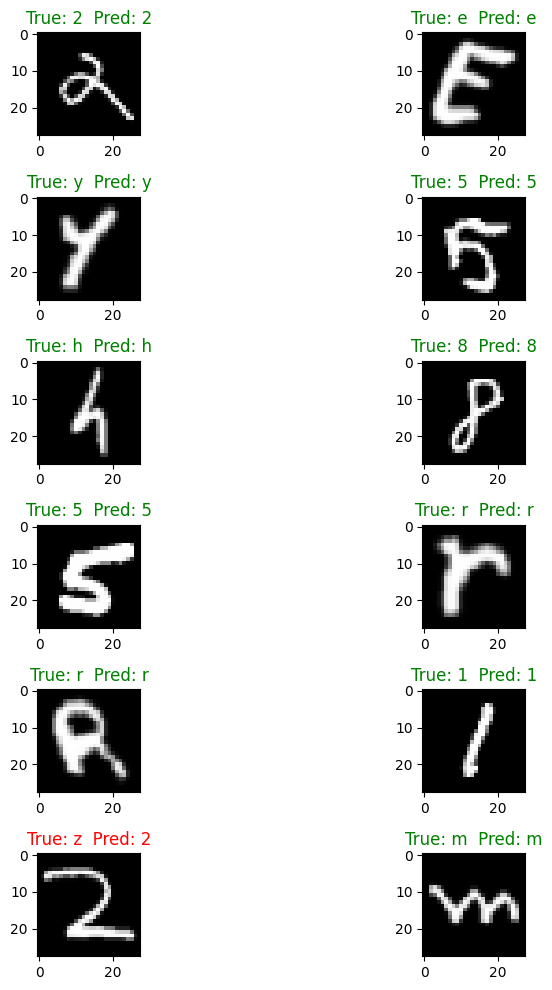

In [68]:
def decode_label(label):
    if label < 10:
        return str(label)               
    return chr(ord('a') + label - 10)


predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)


indices = np.random.choice(len(X_test), 12)

plt.figure(figsize=(10, 10))


for i, idx in enumerate(indices):
    plt.subplot(6, 2, i+1)
    plt.imshow(X_test[idx].squeeze(), cmap='gray')
    
    true_label = Y_test[idx]
    pred_label = predicted_classes[idx]
    
    color = "green" if true_label == pred_label else "red"
    
    plt.title(f"True: {decode_label(true_label)}  Pred: {decode_label(pred_label)}", color=color)
    plt.axis("on")

plt.tight_layout()
plt.show()

